[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/skyexry/urban-mobility-forecast/blob/main/notebooks/06_train_eval.ipynb)

# 06 — Training & Evaluation

Train and compare four models on the 100-station CitiBike demand forecasting task:
- **Historical Average** — statistical baseline
- **LSTM** — pure time-series RNN baseline
- **TCN-only** — pure time-series deep baseline (no spatial)
- **STGNN** — full spatio-temporal model

**Changes from 05:**
- `INPUT_WINDOW = 168` (1 week, up from 72h)
- STGNN: `hidden_channels=32, tcn_channels=64` (up from 16/32)
- STGNN trained with `weighted_log_cosh_loss` (peak weight 3×, same as 05)

Metrics: MAE, RMSE on held-out test set (inverse transformed to original scale).

## Setup

In [1]:
# ── Environment config — change here for AutoDL ──────────────────
import os
if os.path.exists('/root/urban-mobility-forecast'):   # AutoDL
    BASE_DIR = '/root/urban-mobility-forecast'
    DATA_DIR = '/root/urban-mobility-forecast/data'
else:                                                  # Colab
    BASE_DIR = '/content/urban-mobility-forecast'
    DATA_DIR = '/content/drive/MyDrive/citibike'
# ─────────────────────────────────────────────────────────────────
print(f'BASE_DIR: {BASE_DIR}')
print(f'DATA_DIR: {DATA_DIR}')

BASE_DIR: /root/urban-mobility-forecast
DATA_DIR: /root/urban-mobility-forecast/data


In [2]:
!git clone https://github.com/skyexry/urban-mobility-forecast.git 2>/dev/null || git -C urban-mobility-forecast pull

remote: Enumerating objects: 8, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 5 (delta 4), reused 5 (delta 4), pack-reused 0 (from 0)
Unpacking objects: 100% (5/5), 4.05 KiB | 691.00 KiB/s, done.
From https://github.com/skyexry/urban-mobility-forecast
   573dcb4..c28bd9e  main       -> origin/main
Updating 573dcb4..c28bd9e
Fast-forward
 notebooks/05_train_eval.ipynb |    6 +-
 notebooks/06_train_eval.ipynb | 1008 +++++++++++++++++++++++++++++++++++++++++
 2 files changed, 1011 insertions(+), 3 deletions(-)
 create mode 100644 notebooks/06_train_eval.ipynb


In [3]:
import sys

if BASE_DIR == '/content/urban-mobility-forecast':    # Colab only
    from google.colab import drive
    drive.mount('/content/drive')

!pip install torch-geometric -q
sys.path.append(BASE_DIR)

In [4]:
import importlib, numpy as np, pandas as pd
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import joblib, warnings
warnings.filterwarnings('ignore')

def load_module(name, path):
    spec = importlib.util.spec_from_file_location(name, path)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod

features_mod = load_module('features', f'{BASE_DIR}/preprocessing/features.py')
from model.stconv import build_edge_index
from model.stgnn import STGNN
from model.tcn import TCNBlock

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')


libgomp: Invalid value for environment variable OMP_NUM_THREADS

libgomp: Invalid value for environment variable OMP_NUM_THREADS


Device: cuda


## 1. Load Data

Load the filtered demand time series, station metadata, and pre-built graph from Drive.

In [5]:
df       = pd.read_parquet(f'{DATA_DIR}/hourly_demand_filtered.parquet')
stations = pd.read_parquet(f'{DATA_DIR}/stations_final.parquet')
df['hour'] = pd.to_datetime(df['hour'])

edge_index  = torch.tensor(np.load(f'{DATA_DIR}/edge_index.npy'),  dtype=torch.long).to(DEVICE)
edge_weight = torch.tensor(np.load(f'{DATA_DIR}/edge_weight.npy'), dtype=torch.float).to(DEVICE)

print(f'Stations   : {df["start_station_id"].nunique()}')
print(f'Date range : {df["hour"].min()} → {df["hour"].max()}')
print(f'edge_index : {edge_index.shape}')

Stations   : 100
Date range : 2024-01-01 00:00:00 → 2025-12-31 23:00:00
edge_index : torch.Size([2, 656])


## 2. Build Demand Matrix & Time Features

Pivot sparse data into dense `(T, N)` matrix and generate cyclic time encodings.

In [6]:
station_ids = stations['start_station_id'].tolist()
demand_matrix, hours = features_mod.build_demand_matrix(df, station_ids)
time_feats = features_mod.build_time_features(pd.Series(hours))
print(f'demand_matrix : {demand_matrix.shape}')
print(f'time_features : {time_feats.shape}')

demand_matrix : (16808, 100)
time_features : (16808, 6)


In [7]:
# Fetch hourly NYC weather (Open-Meteo, no API key required)
print("Fetching weather data from Open-Meteo (NYC 2024–2025)...")
weather_df  = features_mod.fetch_weather_data('2024-01-01', '2025-12-31')
weather_raw = features_mod.build_weather_features(weather_df, hours)
print(f'weather_raw : {weather_raw.shape}  (T x 9)')
print('Features: temp, dewpoint, humidity, pressure, wind_u/v, gust_u/v, precip')

Fetching weather data from Open-Meteo (NYC 2024–2025)...
weather_raw : (16808, 9)  (T x 9)
Features: temp, dewpoint, humidity, pressure, wind_u/v, gust_u/v, precip


## 3. Train / Val / Test Split

Split chronologically (70/15/15) to avoid data leakage.
Scaler is fit **only on training data**, then applied to val and test.

In [8]:
T = demand_matrix.shape[0]
split1 = int(T * 0.70)
split2 = int(T * 0.85)

train_demand = demand_matrix[:split1]
val_demand   = demand_matrix[split1:split2]
test_demand  = demand_matrix[split2:]

train_time = time_feats[:split1]
val_time   = time_feats[split1:split2]
test_time  = time_feats[split2:]

# Fit scaler on train only (normalize_demand does log1p internally)
normalized_train, scaler = features_mod.normalize_demand(train_demand)

# Apply log1p first, then scaler.transform (mirrors normalize_demand internals)
normalized_val  = scaler.transform(np.log1p(val_demand).reshape(-1,1)).reshape(val_demand.shape)
normalized_test = scaler.transform(np.log1p(test_demand).reshape(-1,1)).reshape(test_demand.shape)

joblib.dump(scaler, f'{DATA_DIR}/scaler.pkl')

print(f'Train: {train_demand.shape[0]} steps ({train_demand.shape[0]/24:.0f} days)')
print(f'Val  : {val_demand.shape[0]} steps ({val_demand.shape[0]/24:.0f} days)')
print(f'Test : {test_demand.shape[0]} steps ({test_demand.shape[0]/24:.0f} days)')

Train: 11765 steps (490 days)
Val  : 2521 steps (105 days)
Test : 2522 steps (105 days)


In [9]:
# Split and normalize weather — fit scaler on train only (mirrors demand scaler logic)
train_weather_raw = weather_raw[:split1]
val_weather_raw   = weather_raw[split1:split2]
test_weather_raw  = weather_raw[split2:]

norm_train_w, weather_scaler = features_mod.normalize_weather_features(train_weather_raw)
norm_val_w,   _              = features_mod.normalize_weather_features(val_weather_raw,  weather_scaler)
norm_test_w,  _              = features_mod.normalize_weather_features(test_weather_raw, weather_scaler)
joblib.dump(weather_scaler, f'{DATA_DIR}/weather_scaler.pkl')

print(f'z-score range (train): [{norm_train_w[:, :8].min():.2f}, {norm_train_w[:, :8].max():.2f}]')
print(f'precip range  (train):  {norm_train_w[:, 8].min():.2f} – {norm_train_w[:, 8].max():.2f} mm/hr')

z-score range (train): [-5.71, 4.51]
precip range  (train):  0.00 – 19.80 mm/hr


## 4. Sliding Windows & DataLoaders

Slide a **168-hour** (1 week) input / 72-hour output window over each split. Wrap in PyTorch Dataset and DataLoader.

In [10]:
INPUT_WINDOW  = 168
OUTPUT_WINDOW = 72
BATCH_SIZE    = 32

x_demand_train, x_time_train, y_train = features_mod.build_sliding_windows(normalized_train, train_time, INPUT_WINDOW, OUTPUT_WINDOW)
x_demand_val,   x_time_val,   y_val   = features_mod.build_sliding_windows(normalized_val,   val_time,   INPUT_WINDOW, OUTPUT_WINDOW)
x_demand_test,  x_time_test,  y_test  = features_mod.build_sliding_windows(normalized_test,  test_time,  INPUT_WINDOW, OUTPUT_WINDOW)

class CitiBikeDataset(Dataset):
    def __init__(self, x_demand, x_time, y):
        self.x_demand = torch.tensor(x_demand, dtype=torch.float32)
        self.x_time   = torch.tensor(x_time,   dtype=torch.float32)
        self.y        = torch.tensor(y,         dtype=torch.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.x_demand[i], self.x_time[i], self.y[i]

train_loader = DataLoader(CitiBikeDataset(x_demand_train, x_time_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(CitiBikeDataset(x_demand_val,   x_time_val,   y_val),   batch_size=BATCH_SIZE)
test_loader  = DataLoader(CitiBikeDataset(x_demand_test,  x_time_test,  y_test),  batch_size=BATCH_SIZE)
print(f'Train batches: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}')

Samples  : 11526
x_demand : (11526, 100, 168, 1)
x_time   : (11526, 168, 6)
y        : (11526, 100, 72, 1)
Samples  : 2282
x_demand : (2282, 100, 168, 1)
x_time   : (2282, 168, 6)
y        : (2282, 100, 72, 1)
Samples  : 2283
x_demand : (2283, 100, 168, 1)
x_time   : (2283, 168, 6)
y        : (2283, 100, 72, 1)
Train batches: 361, Val: 72, Test: 72


In [11]:
# Weather sliding windows — same demand/time splits, adds x_weather branch
x_d_tr_w, x_t_tr_w, x_w_tr, y_tr_w = features_mod.build_sliding_windows(
    normalized_train, train_time, INPUT_WINDOW, OUTPUT_WINDOW, norm_train_w)
x_d_va_w, x_t_va_w, x_w_va, y_va_w = features_mod.build_sliding_windows(
    normalized_val,   val_time,   INPUT_WINDOW, OUTPUT_WINDOW, norm_val_w)
x_d_te_w, x_t_te_w, x_w_te, y_te_w = features_mod.build_sliding_windows(
    normalized_test,  test_time,  INPUT_WINDOW, OUTPUT_WINDOW, norm_test_w)

class CitiBikeWeatherDataset(Dataset):
    def __init__(self, x_d, x_t, x_w, y):
        self.x_d = torch.tensor(x_d, dtype=torch.float32)
        self.x_t = torch.tensor(x_t, dtype=torch.float32)
        self.x_w = torch.tensor(x_w, dtype=torch.float32)
        self.y   = torch.tensor(y,   dtype=torch.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.x_d[i], self.x_t[i], self.x_w[i], self.y[i]

train_w_loader = DataLoader(CitiBikeWeatherDataset(x_d_tr_w, x_t_tr_w, x_w_tr, y_tr_w), batch_size=BATCH_SIZE, shuffle=True)
val_w_loader   = DataLoader(CitiBikeWeatherDataset(x_d_va_w, x_t_va_w, x_w_va, y_va_w), batch_size=BATCH_SIZE)
test_w_loader  = DataLoader(CitiBikeWeatherDataset(x_d_te_w, x_t_te_w, x_w_te, y_te_w), batch_size=BATCH_SIZE)
print(f'Weather DataLoaders — Train: {len(train_w_loader)}, Val: {len(val_w_loader)}, Test: {len(test_w_loader)}')

Samples  : 11526
x_demand : (11526, 100, 168, 1)
x_time   : (11526, 168, 6)
y        : (11526, 100, 72, 1)
x_weather: (11526, 168, 9)
Samples  : 2282
x_demand : (2282, 100, 168, 1)
x_time   : (2282, 168, 6)
y        : (2282, 100, 72, 1)
x_weather: (2282, 168, 9)
Samples  : 2283
x_demand : (2283, 100, 168, 1)
x_time   : (2283, 168, 6)
y        : (2283, 100, 72, 1)
x_weather: (2283, 168, 9)
Weather DataLoaders — Train: 361, Val: 72, Test: 72


## 5. Training Utilities

Shared training loop, early stopping, and evaluation functions used by all models.

In [12]:
from tqdm import tqdm

def log_cosh_loss(pred, target):
    return torch.log(torch.cosh(pred - target)).mean()

def weighted_log_cosh_loss(pred, target, alpha=2.0):
    loss = torch.log(torch.cosh(pred - target))
    # higher weight where demand is high (normalized space: 0→1)
    weight = 1.0 + alpha * torch.clamp(target, 0, 1)
    return (loss * weight).mean()

def train_epoch(model, loader, optimizer, loss_fn, forward_fn, epoch=None):
    model.train()
    total = 0
    desc = f'Epoch {epoch:3d} [train]' if epoch else 'train'
    pbar = tqdm(loader, desc=desc, leave=False)
    for x_d, x_t, y in pbar:
        x_d, x_t, y = x_d.to(DEVICE), x_t.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        pred = forward_fn(model, x_d, x_t)
        loss = loss_fn(pred, y.squeeze(-1))
        loss.backward()
        optimizer.step()
        total += loss.item()
        pbar.set_postfix({'batch_loss': f'{loss.item():.4f}'})
    return total / len(loader)

def eval_epoch(model, loader, forward_fn, epoch=None):
    model.eval()
    mae_total, mse_total = 0, 0
    pbar = tqdm(loader, desc='         [val]  ', leave=False)
    with torch.no_grad():
        for x_d, x_t, y in pbar:
            x_d, x_t, y = x_d.to(DEVICE), x_t.to(DEVICE), y.to(DEVICE)
            pred = forward_fn(model, x_d, x_t)
            diff = pred - y.squeeze(-1)
            mae_total += diff.abs().mean().item()
            mse_total += (diff ** 2).mean().item()
    n = len(loader)
    return mae_total / n, (mse_total / n) ** 0.5

def run_training(model, train_loader, val_loader, forward_fn,
                 lr=1e-3, epochs=100, patience=10,
                 save_path=None, checkpoint_every=None, loss_fn=None):
    if loss_fn is None:
        loss_fn = log_cosh_loss
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5)
    best_val, wait, history = float('inf'), 0, []

    for epoch in range(1, epochs + 1):
        tr_loss = train_epoch(model, train_loader, optimizer, loss_fn, forward_fn, epoch=epoch)
        vl_mae, vl_rmse = eval_epoch(model, val_loader, forward_fn, epoch=epoch)
        history.append((tr_loss, vl_mae, vl_rmse))
        scheduler.step(vl_mae)
        lr_now = optimizer.param_groups[0]['lr']

        print(f'Epoch {epoch:3d} | loss {tr_loss:.4f} | val MAE {vl_mae:.4f} | val RMSE {vl_rmse:.4f} | best {best_val:.4f} | patience {wait}/{patience} | lr {lr_now:.2e}')

        if vl_mae < best_val:
            best_val, wait = vl_mae, 0
            if save_path:
                torch.save(model.state_dict(), save_path)
        else:
            wait += 1
            if wait >= patience:
                print(f'→ Early stop @ epoch {epoch}')
                break

        if checkpoint_every and epoch % checkpoint_every == 0 and save_path:
            ckpt = save_path.replace('.pth', f'_ckpt{epoch}.pth')
            torch.save(model.state_dict(), ckpt)

    return history

def compute_metrics(y_true, y_pred, scaler):
    y_true = features_mod.inverse_transform_demand(y_true, scaler)
    y_pred = features_mod.inverse_transform_demand(y_pred, scaler)
    mae  = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    return dict(MAE=mae, RMSE=rmse)

def get_predictions(model, loader, forward_fn):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for x_d, x_t, y in tqdm(loader, desc='Predicting', leave=False):
            x_d, x_t = x_d.to(DEVICE), x_t.to(DEVICE)
            preds.append(forward_fn(model, x_d, x_t).cpu().numpy())
            trues.append(y.squeeze(-1).numpy())
    return np.concatenate(preds), np.concatenate(trues)


## 6. Baseline — Historical Average

Predicts the mean demand for each station and hour-of-day computed from the training set.
No learning required — serves as the lower bound.

In [13]:
# For each hour-of-day (0–23), compute mean demand per station over training set
N = normalized_train.shape[1]
T_train = normalized_train.shape[0]
hod_train = np.array([h.hour for h in hours[:T_train]])

ha_pred = np.zeros((24, N))
for h in range(24):
    mask = hod_train == h
    ha_pred[h] = normalized_train[mask].mean(axis=0)

# Evaluate on test set
hod_test = np.array([h.hour for h in hours[split2:]])
y_true_ha, y_pred_ha = [], []
for i in range(INPUT_WINDOW, len(normalized_test) - OUTPUT_WINDOW + 1):
    y_true_ha.append(normalized_test[i:i+OUTPUT_WINDOW])
    pred_hours = hod_test[i:i+OUTPUT_WINDOW]
    y_pred_ha.append(ha_pred[pred_hours])

y_true_ha = np.stack(y_true_ha)  # (samples, OUTPUT_WINDOW, N)
y_pred_ha = np.stack(y_pred_ha)

metrics_ha = compute_metrics(y_true_ha, y_pred_ha, scaler)
print('Historical Average:', {k: f"{v:.4f}" for k, v in metrics_ha.items()})

Historical Average: {'MAE': '13.1798', 'RMSE': '21.1992'}


## 7. Baseline — LSTM

Per-node LSTM trained independently on each station's demand sequence.
Captures temporal patterns but has no spatial awareness.

In [14]:
# ── LSTMModel Definition ──────────────────────────────────────────────────────
class LSTMModel(nn.Module):
    def __init__(self, num_nodes, input_window, output_window, hidden=64, num_layers=2):
        super().__init__()
        self.num_nodes = num_nodes
        self.output_window = output_window
        self.lstm = nn.LSTM(1, hidden, num_layers, batch_first=True, dropout=0.2)
        self.fc   = nn.Linear(hidden, output_window)

    def forward(self, x_demand, x_time=None):
        b, N, T, _ = x_demand.shape
        x = x_demand.reshape(b * N, T, 1)
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out.reshape(b, N, self.output_window)


In [15]:
# ── Train LSTM ────────────────────────────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

lstm_model   = LSTMModel(num_nodes=100, input_window=INPUT_WINDOW, output_window=OUTPUT_WINDOW).to(DEVICE)
lstm_forward = lambda model, x_d, x_t: model(x_d, x_t)
print(f'LSTM parameters: {sum(p.numel() for p in lstm_model.parameters()):,}')
history_lstm = run_training(
    lstm_model, train_loader, val_loader, lstm_forward,
    save_path=f'{DATA_DIR}/lstm_06_best.pth'
)


LSTM parameters: 55,112


Epoch   1 | loss 0.0492 | val MAE 0.2286 | val RMSE 0.2913 | best inf | patience 0/10 | lr 1.00e-03


Epoch   2 | loss 0.0313 | val MAE 0.2123 | val RMSE 0.2743 | best 0.2286 | patience 0/10 | lr 1.00e-03


Epoch   3 | loss 0.0303 | val MAE 0.2072 | val RMSE 0.2704 | best 0.2123 | patience 0/10 | lr 1.00e-03


Epoch   4 | loss 0.0295 | val MAE 0.2038 | val RMSE 0.2658 | best 0.2072 | patience 0/10 | lr 1.00e-03


...

Epoch  57 | loss 0.0217 | val MAE 0.1713 | val RMSE 0.2316 | best 0.1703 | patience 5/10 | lr 2.50e-04


Epoch  58 | loss 0.0215 | val MAE 0.1712 | val RMSE 0.2322 | best 0.1703 | patience 6/10 | lr 2.50e-04


Epoch  59 | loss 0.0214 | val MAE 0.1724 | val RMSE 0.2309 | best 0.1703 | patience 7/10 | lr 2.50e-04


Epoch  60 | loss 0.0214 | val MAE 0.1722 | val RMSE 0.2321 | best 0.1703 | patience 8/10 | lr 2.50e-04


Epoch  61 | loss 0.0214 | val MAE 0.1706 | val RMSE 0.2315 | best 0.1703 | patience 9/10 | lr 2.50e-04
→ Early stop @ epoch 61


In [16]:
# ── Load LSTM from Checkpoint ─────────────────────────────────────────────────
lstm_model   = LSTMModel(num_nodes=100, input_window=INPUT_WINDOW, output_window=OUTPUT_WINDOW).to(DEVICE)
lstm_forward = lambda model, x_d, x_t: model(x_d, x_t)
lstm_model.load_state_dict(torch.load(f'{DATA_DIR}/lstm_06_best.pth', map_location=DEVICE))
preds_lstm, trues_lstm = get_predictions(lstm_model, test_loader, lstm_forward)
metrics_lstm = compute_metrics(trues_lstm, preds_lstm, scaler)
print('LSTM:', {k: f"{v:.4f}" for k, v in metrics_lstm.items()})


LSTM: {'MAE': '8.1684', 'RMSE': '13.2704'}


## 8. TCN-only Baseline

Temporal Convolutional Network operating per-node — captures temporal patterns with dilated convolutions but no spatial graph structure.

In [17]:
# ── TCNOnlyModel Definition ───────────────────────────────────────────────────
class TCNOnlyModel(nn.Module):
    def __init__(self, num_nodes, input_window, output_window,
                 tcn_channels=32, time_channels=6, num_layers=2):
        super().__init__()
        self.num_nodes = num_nodes
        self.output_window = output_window
        self.demand_tcn = TCNBlock(in_channels=1,             out_channels=tcn_channels, num_layers=num_layers)
        self.time_tcn   = TCNBlock(in_channels=time_channels, out_channels=tcn_channels, num_layers=num_layers)
        self.fc = nn.Linear(tcn_channels * 2, output_window)

    def forward(self, x_demand, x_time):
        b, N, T, _ = x_demand.shape
        x_d = x_demand.reshape(b * N, T, 1).permute(0, 2, 1)
        d_out = self.demand_tcn(x_d)[:, :, -1]
        x_t = x_time.permute(0, 2, 1)
        t_out = self.time_tcn(x_t)[:, :, -1]
        t_out = t_out.unsqueeze(1).expand(-1, N, -1).reshape(b * N, -1)
        fused = torch.cat([d_out, t_out], dim=-1)
        out = self.fc(fused).reshape(b, N, self.output_window)
        return out


In [18]:
# ── Train TCN ─────────────────────────────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

tcn_model   = TCNOnlyModel(num_nodes=100, input_window=INPUT_WINDOW, output_window=OUTPUT_WINDOW).to(DEVICE)
tcn_forward = lambda model, x_d, x_t: model(x_d, x_t)
print(f'TCN-only parameters: {sum(p.numel() for p in tcn_model.parameters()):,}')
history_tcn = run_training(
    tcn_model, train_loader, val_loader, tcn_forward,
    save_path=f'{DATA_DIR}/tcn_06_best.pth'
)


TCN-only parameters: 25,096


Epoch   1 | loss 0.0579 | val MAE 0.2263 | val RMSE 0.2881 | best inf | patience 0/10 | lr 1.00e-03


Epoch   2 | loss 0.0339 | val MAE 0.2120 | val RMSE 0.2718 | best 0.2263 | patience 0/10 | lr 1.00e-03


Epoch   3 | loss 0.0309 | val MAE 0.2108 | val RMSE 0.2689 | best 0.2120 | patience 0/10 | lr 1.00e-03


Epoch   4 | loss 0.0296 | val MAE 0.2046 | val RMSE 0.2623 | best 0.2108 | patience 0/10 | lr 1.00e-03


...

Epoch  30 | loss 0.0261 | val MAE 0.1970 | val RMSE 0.2527 | best 0.1919 | patience 5/10 | lr 5.00e-04


Epoch  31 | loss 0.0259 | val MAE 0.1979 | val RMSE 0.2529 | best 0.1919 | patience 6/10 | lr 5.00e-04


Epoch  32 | loss 0.0259 | val MAE 0.1946 | val RMSE 0.2505 | best 0.1919 | patience 7/10 | lr 5.00e-04


Epoch  33 | loss 0.0259 | val MAE 0.1926 | val RMSE 0.2493 | best 0.1919 | patience 8/10 | lr 5.00e-04


Epoch  34 | loss 0.0259 | val MAE 0.2034 | val RMSE 0.2577 | best 0.1919 | patience 9/10 | lr 5.00e-04
→ Early stop @ epoch 34


In [19]:
# ── Load TCN from Checkpoint ──────────────────────────────────────────────────
tcn_model   = TCNOnlyModel(num_nodes=100, input_window=INPUT_WINDOW, output_window=OUTPUT_WINDOW).to(DEVICE)
tcn_forward = lambda model, x_d, x_t: model(x_d, x_t)
tcn_model.load_state_dict(torch.load(f'{DATA_DIR}/tcn_06_best.pth', map_location=DEVICE))
preds_tcn, trues_tcn = get_predictions(tcn_model, test_loader, tcn_forward)
metrics_tcn = compute_metrics(trues_tcn, preds_tcn, scaler)
print('TCN-only:', {k: f"{v:.4f}" for k, v in metrics_tcn.items()})


TCN-only: {'MAE': '9.6891', 'RMSE': '16.3742'}


## 9. STGNN — Spatio-Temporal Graph Neural Network

Full STGNN: ChebConv spatial layers + demand TCN + time TCN, fused with self-attention decoder.

**06 changes:** `hidden_channels=32, tcn_channels=64` (up from 16/32); trained with `weighted_log_cosh_loss`.

In [20]:
# ── Train STGNN ───────────────────────────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

stgnn_model   = STGNN(num_nodes=100, input_window=INPUT_WINDOW, output_window=OUTPUT_WINDOW,
                      hidden_channels=32, tcn_channels=64).to(DEVICE)
stgnn_forward = lambda model, x_d, x_t: model(x_d, x_t, edge_index, edge_weight)
print(f'STGNN parameters: {sum(p.numel() for p in stgnn_model.parameters()):,}')
history_stgnn = run_training(
    stgnn_model, train_loader, val_loader, stgnn_forward,
    loss_fn=weighted_log_cosh_loss,
    save_path=f'{DATA_DIR}/stgnn_06_best.pth',
    checkpoint_every=10
)


STGNN parameters: 271,688


Epoch   1 | loss 0.0544 | val MAE 0.2030 | val RMSE 0.2706 | best inf | patience 0/10 | lr 1.00e-03


Epoch   2 | loss 0.0320 | val MAE 0.1916 | val RMSE 0.2595 | best 0.2030 | patience 0/10 | lr 1.00e-03


Epoch   3 | loss 0.0294 | val MAE 0.1841 | val RMSE 0.2490 | best 0.1916 | patience 0/10 | lr 1.00e-03


Epoch   4 | loss 0.0281 | val MAE 0.1800 | val RMSE 0.2450 | best 0.1841 | patience 0/10 | lr 1.00e-03


...

Epoch  23 | loss 0.0223 | val MAE 0.1754 | val RMSE 0.2436 | best 0.1694 | patience 5/10 | lr 5.00e-04


Epoch  24 | loss 0.0216 | val MAE 0.1722 | val RMSE 0.2395 | best 0.1694 | patience 6/10 | lr 5.00e-04


Epoch  25 | loss 0.0215 | val MAE 0.1721 | val RMSE 0.2372 | best 0.1694 | patience 7/10 | lr 5.00e-04


Epoch  26 | loss 0.0214 | val MAE 0.1715 | val RMSE 0.2398 | best 0.1694 | patience 8/10 | lr 5.00e-04


Epoch  27 | loss 0.0213 | val MAE 0.1722 | val RMSE 0.2399 | best 0.1694 | patience 9/10 | lr 5.00e-04
→ Early stop @ epoch 27


In [21]:
# ── Load STGNN from Checkpoint ────────────────────────────────────────────────
stgnn_model   = STGNN(num_nodes=100, input_window=INPUT_WINDOW, output_window=OUTPUT_WINDOW,
                      hidden_channels=32, tcn_channels=64).to(DEVICE)
stgnn_forward = lambda model, x_d, x_t: model(x_d, x_t, edge_index, edge_weight)
stgnn_model.load_state_dict(torch.load(f'{DATA_DIR}/stgnn_06_best.pth', map_location=DEVICE))
preds_stgnn, trues_stgnn = get_predictions(stgnn_model, test_loader, stgnn_forward)
metrics_stgnn = compute_metrics(trues_stgnn, preds_stgnn, scaler)
print('STGNN:', {k: f"{v:.4f}" for k, v in metrics_stgnn.items()})


STGNN: {'MAE': '8.1000', 'RMSE': '13.1917'}


## 10. STGNN + Weather Branch

Adds a weather TCN branch (9 features: temp, humidity, wind, pressure, precipitation) alongside the spatial and time branches.

**06 changes:** `hidden_channels=32, tcn_channels=64`.

In [22]:
# ── Train STGNN+Weather ───────────────────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

def train_epoch_w(model, loader, optimizer, loss_fn, epoch=None):
    model.train(); total = 0
    for x_d, x_t, x_w, y in tqdm(loader, desc=f'Epoch {epoch:3d} [train]', leave=False):
        x_d, x_t, x_w, y = x_d.to(DEVICE), x_t.to(DEVICE), x_w.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        loss = loss_fn(model(x_d, x_t, edge_index, edge_weight, x_w), y.squeeze(-1))
        loss.backward(); optimizer.step(); total += loss.item()
    return total / len(loader)

def eval_epoch_w(model, loader):
    model.eval(); mae_t = mse_t = 0
    with torch.no_grad():
        for x_d, x_t, x_w, y in tqdm(loader, desc='         [val]  ', leave=False):
            x_d, x_t, x_w, y = x_d.to(DEVICE), x_t.to(DEVICE), x_w.to(DEVICE), y.to(DEVICE)
            diff = model(x_d, x_t, edge_index, edge_weight, x_w) - y.squeeze(-1)
            mae_t += diff.abs().mean().item(); mse_t += (diff**2).mean().item()
    return mae_t/len(loader), (mse_t/len(loader))**0.5

def run_training_w(model, tr_loader, va_loader, lr=1e-3, epochs=100, patience=10, save_path=None):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=5)
    loss_fn = log_cosh_loss
    best, wait, hist = float('inf'), 0, []
    for ep in range(1, epochs+1):
        tr = train_epoch_w(model, tr_loader, opt, loss_fn, ep)
        va, vr = eval_epoch_w(model, va_loader)
        hist.append((tr, va, vr))
        scheduler.step(va)
        lr_now = opt.param_groups[0]['lr']
        print(f'Epoch {ep:3d} | loss {tr:.4f} | val MAE {va:.4f} | rmse {vr:.4f} | best {best:.4f} | patience {wait}/{patience} | lr {lr_now:.2e}')
        if va < best:
            best, wait = va, 0
            if save_path: torch.save(model.state_dict(), save_path)
        else:
            wait += 1
            if wait >= patience: print(f'→ Early stop @ epoch {ep}'); break
    return hist

stgnn_w = STGNN(num_nodes=100, input_window=INPUT_WINDOW, output_window=OUTPUT_WINDOW,
                weather_channels=9, hidden_channels=32, tcn_channels=64).to(DEVICE)
print(f'STGNN+Weather parameters: {sum(p.numel() for p in stgnn_w.parameters()):,}')
history_stgnn_w = run_training_w(
    stgnn_w, train_w_loader, val_w_loader,
    save_path=f'{DATA_DIR}/stgnn_weather_06_best.pth'
)


STGNN+Weather parameters: 515,080


Epoch   1 | loss 0.0462 | val MAE 0.2013 | rmse 0.2671 | best inf | patience 0/10 | lr 1.00e-03


Epoch   2 | loss 0.0293 | val MAE 0.1926 | rmse 0.2583 | best 0.2013 | patience 0/10 | lr 1.00e-03


Epoch   3 | loss 0.0259 | val MAE 0.1883 | rmse 0.2518 | best 0.1926 | patience 0/10 | lr 1.00e-03


Epoch   4 | loss 0.0238 | val MAE 0.1876 | rmse 0.2557 | best 0.1883 | patience 0/10 | lr 1.00e-03


...

Epoch  22 | loss 0.0170 | val MAE 0.1762 | rmse 0.2431 | best 0.1760 | patience 5/10 | lr 5.00e-04


Epoch  23 | loss 0.0163 | val MAE 0.1792 | rmse 0.2456 | best 0.1760 | patience 6/10 | lr 5.00e-04


Epoch  24 | loss 0.0162 | val MAE 0.1806 | rmse 0.2483 | best 0.1760 | patience 7/10 | lr 5.00e-04


Epoch  25 | loss 0.0161 | val MAE 0.1771 | rmse 0.2458 | best 0.1760 | patience 8/10 | lr 5.00e-04


Epoch  26 | loss 0.0161 | val MAE 0.1781 | rmse 0.2426 | best 0.1760 | patience 9/10 | lr 5.00e-04
→ Early stop @ epoch 26


In [23]:
# ── Load STGNN+Weather from Checkpoint ────────────────────────────────────────
stgnn_w = STGNN(num_nodes=100, input_window=INPUT_WINDOW, output_window=OUTPUT_WINDOW,
                weather_channels=9, hidden_channels=32, tcn_channels=64).to(DEVICE)
stgnn_w.load_state_dict(torch.load(f'{DATA_DIR}/stgnn_weather_06_best.pth', map_location=DEVICE))
stgnn_w.eval()
preds_sw, trues_sw = [], []
with torch.no_grad():
    for x_d, x_t, x_w, y in tqdm(test_w_loader, desc='Predicting', leave=False):
        preds_sw.append(stgnn_w(x_d.to(DEVICE), x_t.to(DEVICE), edge_index, edge_weight, x_w.to(DEVICE)).cpu().numpy())
        trues_sw.append(y.squeeze(-1).numpy())
preds_sw = np.concatenate(preds_sw)
trues_sw = np.concatenate(trues_sw)
metrics_stgnn_w = compute_metrics(trues_sw, preds_sw, scaler)
print('STGNN+Weather:', {k: f"{v:.4f}" for k, v in metrics_stgnn_w.items()})


STGNN+Weather: {'MAE': '8.4910', 'RMSE': '14.0505'}


## 11. Loss Curves

Visualize training and validation loss for each learned model.

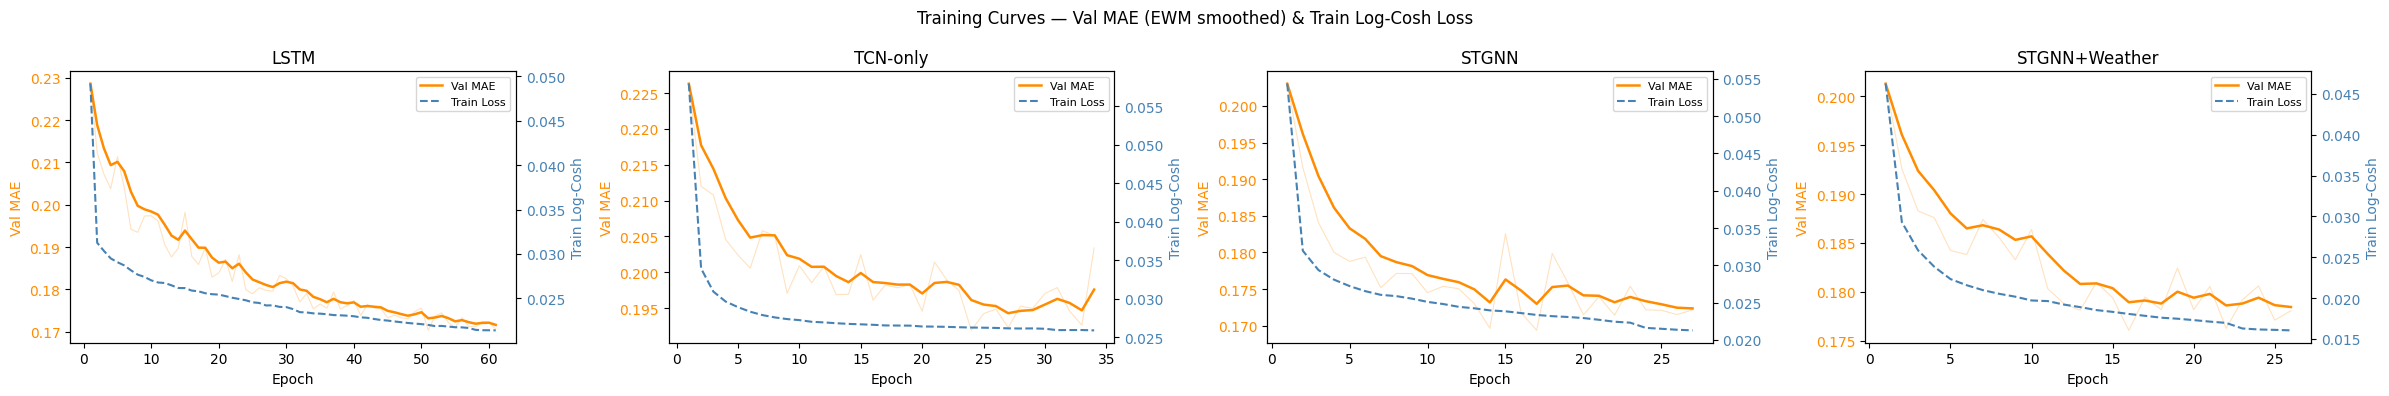

In [24]:
histories = {
    'LSTM':         locals().get('history_lstm'),
    'TCN-only':     locals().get('history_tcn'),
    'STGNN':        locals().get('history_stgnn'),
    'STGNN+Weather':locals().get('history_stgnn_w'),
}
available = {k: v for k, v in histories.items() if v is not None}

if not available:
    print('No training histories available — run the Train cells to plot loss curves.')
else:
    fig, axes = plt.subplots(1, len(available), figsize=(6 * len(available), 4))
    if len(available) == 1:
        axes = [axes]
    for ax, (name, history) in zip(axes, available.items()):
        tr = [h[0] for h in history]
        vl = [h[1] for h in history]
        epochs = range(1, len(history) + 1)
        ax2 = ax.twinx()
        line1,  = ax.plot(epochs, vl,  color='darkorange', alpha=0.25, linewidth=0.8)
        line1s, = ax.plot(epochs, pd.Series(vl).ewm(span=5).mean(),
                          color='darkorange', linewidth=1.8, label='Val MAE')
        line2,  = ax2.plot(epochs, tr, color='steelblue', linestyle='--', linewidth=1.5, label='Train Loss')
        ax.set_title(name)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Val MAE', color='darkorange')
        ax2.set_ylabel('Train Log-Cosh', color='steelblue')
        ax.tick_params(axis='y', labelcolor='darkorange')
        ax2.tick_params(axis='y', labelcolor='steelblue')
        lines = [line1s, line2]
        ax.legend(lines, [l.get_label() for l in lines], loc='upper right', fontsize=8)
    plt.suptitle('Training Curves — Val MAE (EWM smoothed) & Train Log-Cosh Loss', fontsize=12)
    plt.tight_layout()
    plt.show()


## 12. Results Comparison

Summary table comparing all five models on the test set (original demand scale).

In [25]:
results = pd.DataFrame([
    {'Model': 'Historical Average', **metrics_ha},
    {'Model': 'LSTM',              **metrics_lstm},
    {'Model': 'TCN-only',          **metrics_tcn},
    {'Model': 'STGNN',             **metrics_stgnn},
    {'Model': 'STGNN+Weather',     **metrics_stgnn_w},
]).set_index('Model').round(4)

print(results.to_string())
results


                        MAE     RMSE
Model                               
Historical Average  13.1798  21.1992
LSTM                 8.1684  13.2704
TCN-only             9.6891  16.3742
STGNN                8.1000  13.1917
STGNN+Weather        8.4910  14.0505


,MAE,RMSE
Model,,
Historical Average,13.1798,21.1992
LSTM,8.1684,13.2704
TCN-only,9.6891,16.3742
STGNN,8.1000,13.1917
STGNN+Weather,8.4910,14.0505


## 13. Extended Evaluation

- **Results table**: MAE / RMSE with % improvement over Historical Average baseline
- **72-hour forecast**: predicted vs actual demand for 3 representative stations
- **Error by hour**: peak vs off-peak MAE breakdown
- **Per-station MAE**: which stations are hardest to predict

In [26]:
# Results table (MAE + RMSE only) with relative improvement vs Historical Average baseline
preds_r = features_mod.inverse_transform_demand(preds_stgnn, scaler)  # (samples, 100, 72)
trues_r = features_mod.inverse_transform_demand(trues_stgnn, scaler)

ha_mae, ha_rmse = metrics_ha['MAE'], metrics_ha['RMSE']
rows = []
for name, m in [('Historical Average', metrics_ha), ('LSTM', metrics_lstm),
                ('TCN-only', metrics_tcn), ('STGNN', metrics_stgnn),
                ('STGNN+Weather', metrics_stgnn_w)]:
    pct_mae  = f"−{(ha_mae  - m['MAE'])  / ha_mae  * 100:.1f}%" if name != 'Historical Average' else '—'
    pct_rmse = f"−{(ha_rmse - m['RMSE']) / ha_rmse * 100:.1f}%" if name != 'Historical Average' else '—'
    rows.append({'Model': name, 'MAE': round(m['MAE'], 4), 'RMSE': round(m['RMSE'], 4),
                 'MAE vs HA': pct_mae, 'RMSE vs HA': pct_rmse})

pd.DataFrame(rows).set_index('Model')


,MAE,RMSE,MAE vs HA,RMSE vs HA
Model,,,,
Historical Average,13.1798,21.199200,—,—
LSTM,8.1684,13.270400,−38.0%,−37.4%
TCN-only,9.6891,16.374201,−26.5%,−22.8%
STGNN,8.1000,13.191700,−38.5%,−37.8%
STGNN+Weather,8.4910,14.050500,−35.6%,−33.7%


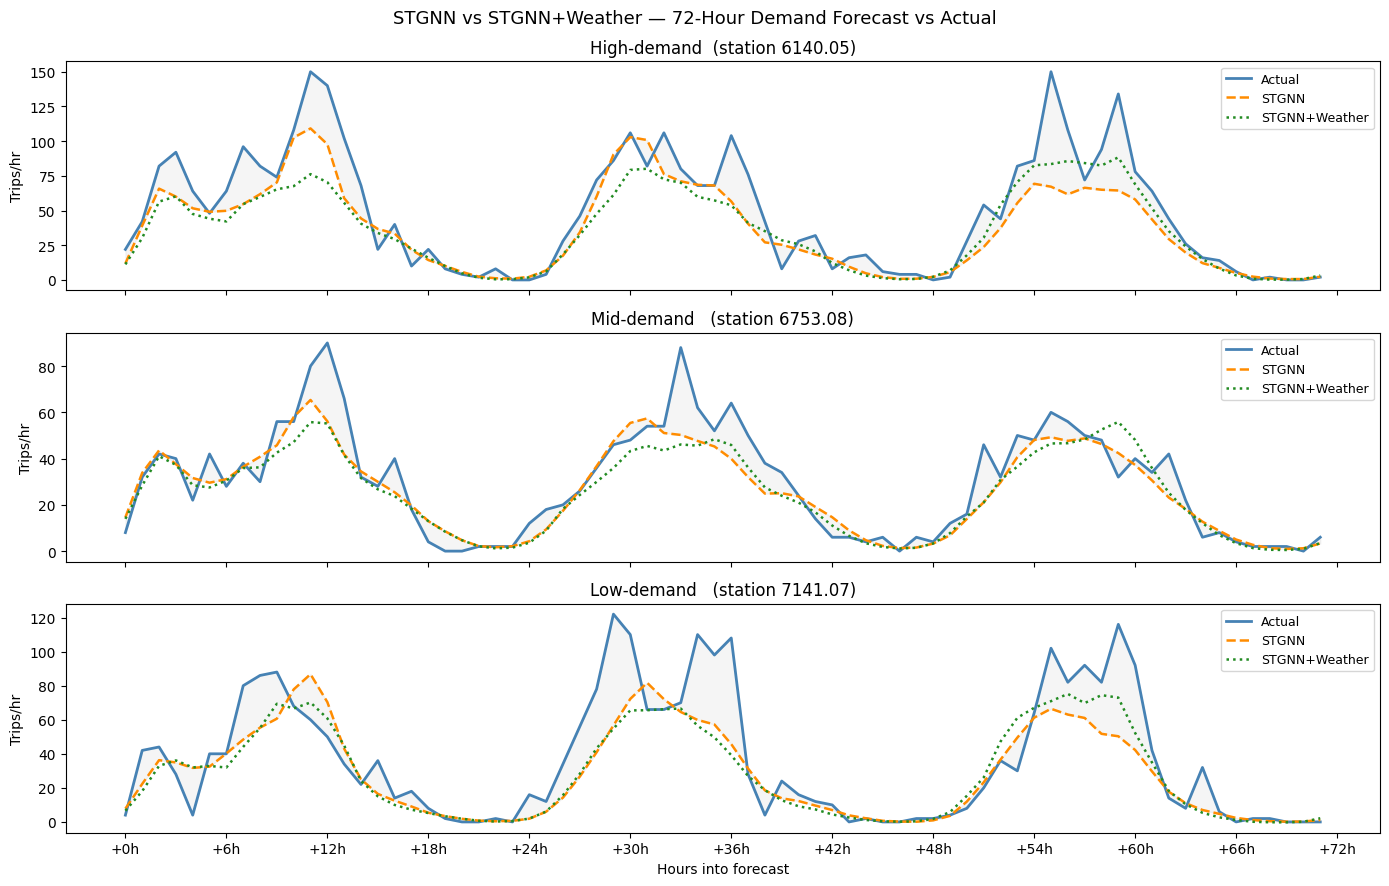

In [27]:
# 72-hour forecast vs actual — 3 representative stations, STGNN vs STGNN+Weather
test_mean = test_demand.mean(axis=0)
high_idx  = int(test_mean.argsort()[-1])
mid_idx   = int(test_mean.argsort()[50])
low_idx   = int(test_mean.argsort()[5])
sample_idx = 200

preds_r  = features_mod.inverse_transform_demand(preds_stgnn, scaler)
trues_r  = features_mod.inverse_transform_demand(trues_stgnn, scaler)
preds_rw = features_mod.inverse_transform_demand(preds_sw,    scaler)

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
for ax, s_idx, label in zip(axes,
    [high_idx, mid_idx, low_idx],
    [f'High-demand  (station {station_ids[high_idx]})',
     f'Mid-demand   (station {station_ids[mid_idx]})',
     f'Low-demand   (station {station_ids[low_idx]})']):
    t  = trues_r[sample_idx, s_idx]
    p  = preds_r[sample_idx, s_idx]
    pw = preds_rw[sample_idx, s_idx]
    ax.plot(t,  color='steelblue',  linewidth=2,   label='Actual')
    ax.plot(p,  color='darkorange', linewidth=1.8, linestyle='--', label='STGNN')
    ax.plot(pw, color='forestgreen',linewidth=1.8, linestyle=':',  label='STGNN+Weather')
    ax.fill_between(range(OUTPUT_WINDOW), t, p, alpha=0.08, color='grey')
    ax.set_ylabel('Trips/hr')
    ax.set_title(label)
    ax.legend(loc='upper right', fontsize=9)

axes[-1].set_xticks(range(0, OUTPUT_WINDOW + 1, 6))
axes[-1].set_xticklabels([f'+{h}h' for h in range(0, OUTPUT_WINDOW + 1, 6)])
axes[-1].set_xlabel('Hours into forecast')
plt.suptitle('STGNN vs STGNN+Weather — 72-Hour Demand Forecast vs Actual', fontsize=13)
plt.tight_layout()
plt.show()


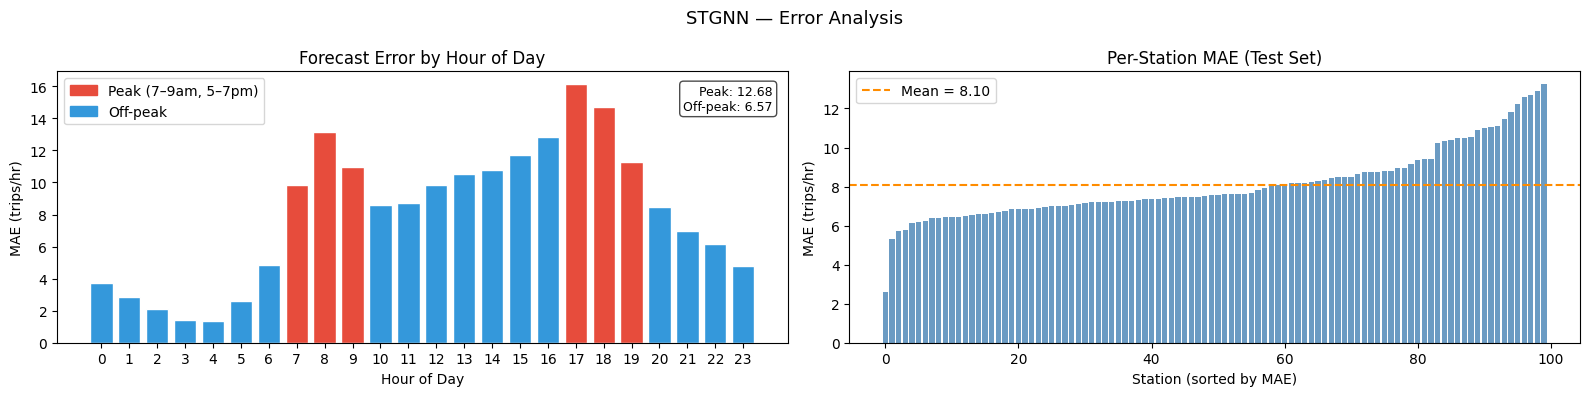

Peak hour MAE:    12.68 trips/hr
Off-peak MAE:     6.57 trips/hr
Best 5 stations:  ['6266.06', '6535.04', '6157.04', '6432.11', '6925.09']
Worst 5 stations: ['6331.01', '6364.07', '6140.05', '6602.03', '6492.08']


In [28]:
from matplotlib.patches import Patch

# MAE by hour of day
hours_hod  = hours.hour.values                                           # (T,)
n_samples  = preds_r.shape[0]
i_idx      = np.arange(n_samples)[:, None]
t_idx      = np.arange(OUTPUT_WINDOW)[None, :]
step_hod   = hours_hod[split2 + INPUT_WINDOW + i_idx + t_idx]           # (n_samples, 72)
err_step   = np.abs(preds_r - trues_r).mean(axis=1)                     # (n_samples, 72)
hourly_mae = np.array([err_step[step_hod == h].mean() for h in range(24)])

peak   = [7, 8, 9, 17, 18, 19]
colors = ['#e74c3c' if h in peak else '#3498db' for h in range(24)]

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Left: MAE by hour of day
ax = axes[0]
ax.bar(range(24), hourly_mae, color=colors, edgecolor='white')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('MAE (trips/hr)')
ax.set_title('Forecast Error by Hour of Day')
ax.set_xticks(range(24))
peak_mae    = np.mean([hourly_mae[h] for h in peak])
offpeak_mae = np.mean([hourly_mae[h] for h in range(24) if h not in peak])
ax.text(0.98, 0.95, f'Peak: {peak_mae:.2f}\nOff-peak: {offpeak_mae:.2f}',
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
ax.legend(handles=[Patch(color='#e74c3c', label='Peak (7–9am, 5–7pm)'),
                   Patch(color='#3498db', label='Off-peak')], loc='upper left')

# Right: per-station MAE
ax2 = axes[1]
station_mae_arr = np.abs(preds_r - trues_r).mean(axis=(0, 2))           # (100,)
sorted_idx = station_mae_arr.argsort()
ax2.bar(range(100), station_mae_arr[sorted_idx], color='steelblue', alpha=0.8)
ax2.axhline(station_mae_arr.mean(), color='darkorange', linestyle='--', linewidth=1.5,
            label=f'Mean = {station_mae_arr.mean():.2f}')
ax2.set_xlabel('Station (sorted by MAE)')
ax2.set_ylabel('MAE (trips/hr)')
ax2.set_title('Per-Station MAE (Test Set)')
ax2.legend()

plt.suptitle('STGNN — Error Analysis', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Peak hour MAE:    {peak_mae:.2f} trips/hr')
print(f'Off-peak MAE:     {offpeak_mae:.2f} trips/hr')
print(f'Best 5 stations:  {[station_ids[i] for i in sorted_idx[:5]]}')
print(f'Worst 5 stations: {[station_ids[i] for i in sorted_idx[-5:]]}')
